# 6. Ordering cells along a lineage

Tutorial 02 put each cell on an edge of the ontology and recorded how far along
that edge it sits. That position is *local*: it says how far a cell has moved
from one cell type towards one other cell type, so 0.5 on one edge and 0.5 on
another are not the same thing and the two cannot be compared.

This tutorial turns those local positions into one ordering per lineage. The
result answers "which of these two cells is further along?" for any two cells of
the same lineage.

**Two things it is not.** It is not a single ordering across the whole dataset:
one number per cell gives two cells on different branches the same value however
different they are, and ranking each lineage on its own is how that is avoided.
And it is not a distance — see the last section, which is the one to read before
quoting any number from it.

The shape of what follows: run it, check the answer against labels the people
who made the data wrote by hand, find one lineage where the check fails, work
out why, and fix it. The failure is the useful part.

## Getting the data

The developing human retina, the same atlas tutorials 03 and 04 use. **If you
have done either of those you already have this file** and the download below
skips itself.

A fetal tissue is the right thing to ask this question of. Tutorials 01 and 02
use adult blood, which is terminally differentiated — there is no maturation
left in it to order. Here there is: the retina builds itself over the weeks this
atlas covers, and progenitors, precursors and mature cells are all present at
once.

> Zuo Z, Cheng X, Ferdous S, *et al.* "Single cell dual-omic atlas of the human
> developing retina." *Nat Commun* **15**, 6792 (2024).
> doi:[10.1038/s41467-024-50853-5](https://doi.org/10.1038/s41467-024-50853-5)

**This download is 3.1 GB and will take a while.** It happens once.

In [1]:
import pathlib
import shutil
import urllib.request

URL = ("https://datasets.cellxgene.cziscience.com/"
       "883270e9-41e6-4c2c-b352-b15c292d2a34.h5ad")
SOURCE = pathlib.Path("retina_fetal.h5ad")

if not SOURCE.exists():
    with urllib.request.urlopen(URL) as response, open(SOURCE, "wb") as handle:
        shutil.copyfileobj(response, handle)

## Step 1. Take a slice, and get back to raw counts

The two preparation steps tutorial 03 explains in full, in one cell. `backed="r"`
leaves the matrix on disk so only the 25,000 rows we ask for are read, and
`.raw.to_adata()` recovers the counts that CELLxGENE files hide behind
normalised values in `.X`.

Take a plain random slice, not a balanced one — forcing the groups to equal
sizes makes every count printed later mean something other than what it says.

In [2]:
import anndata as ad
import numpy as np

full = ad.read_h5ad(SOURCE, backed="r")
rng = np.random.default_rng(0)
chosen = np.sort(rng.choice(full.n_obs, 25_000, replace=False))
adata = full[chosen].to_memory()
full.file.close()

adata = adata.raw.to_adata()
print("largest value:", adata.X.max(), "— whole numbers:",
      float(adata.X.max()) == int(adata.X.max()))

largest value: 3395.0 — whole numbers: True


### Set the authors' own labels aside

This atlas carries hand-written labels in `subclass`. Six of them end in
`Precursor`, and two more — `PRPC` and `NRPC` — name the progenitors that have
not committed to anything yet.

**Nothing between here and Step 5 uses this column.** It is kept back so that
Step 5 can use it as an answer sheet.

In [3]:
authors_label = adata.obs["subclass"].astype(str)

authors_call = np.where(
    authors_label.str.contains("Precursor"), "precursor",
    np.where(authors_label.isin(["PRPC", "NRPC"]), "progenitor", "mature"))

print(sorted(set(authors_label[authors_call == "precursor"])))

['AC Precursor', 'BC Precursor', 'Cone Precursor', 'HC Precursor', 'RGC Precursor', 'Rod Precursor']


## Step 2. Annotate, then run the trajectory analysis

`create_pseudotime_analysis` reads the columns the trajectory step writes, so
that step has to run first. It is not run for you: it is the expensive part and
it has settings you may want to choose.

Note `min_cells_number` below — it decides which cell types are large enough to
keep. You do not have to repeat it in Step 3: whatever you pass here is recorded
on the object and read back, so the two steps agree without your help.

In [4]:
import hector

predictor = hector.HECTOR("human")
predictions = predictor.predict(adata, label_format="name")
predictor.write_predictions(adata, predictions)

hector.create_trajectory_analysis(
    predictor=predictor,
    adata=adata,
    output_file="06_tree.pdf",
    title="Developing human retina",
    label_format="name",
    min_cells_number=20,
)

<environment>/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  ☑️  MLX encoder loaded
  ☑️  MLX CellTypeEmbedder loaded
  ☑️  MLX HPLHead loaded


  📂 Loaded Memory Bank: 100,000 anchor cells
 🎉 Model loaded successfully! 🥳
   Prediction hardware: GPU (Apple M1 Max, MLX)
   Supported cell types: 1407
  [INFO] Making predictions on 25000 cells...
  Settings: top_k=1, use_grit=True, zero_shot=True
  Step 0: Checking gene IDs...
  Step 1: Gene Matching and Reordering ...


  Gene matching: 4983/5000 (99.7% of reference genes found)
  Step 2: Processing expression data...


  MLX adaptive batch size: 16675 (budget 13.6 GB, floor 5.7 GB)


...

[INFO] Pruning cell types below 20 cells: 36 cell types removed.
[INFO] Starting Trajectory Analysis...


[INFO] Layout pipeline: Using PURE ontology DAG
[INFO] Visual pipeline: Building visual edges


[HECTOR] auto-detected stable_source_zone=0.1339, stable_target_zone=0.0229  (mode=auto)


  > Tagged 11976 Transitioning Typical, 12967 Stable Typical, 0 Clustered Atypical, and 0 Unclustered Atypical cells.
  Cells: 24943 | Nodes: 41 | Edges: 50 (inferred paths: 0)
Plot generating......


✅ Saved: 06_tree.pdf


## Step 3. Order the cells

One call, with nothing to set. It prints the lineages it worked out, what
decided the order, and the `min_cells_number` it read back from Step 2.

In [5]:
hector.create_pseudotime_analysis(
    predictor=predictor,
    adata=adata,
)


[Pseudotime] 39 cell types occupied, 741 pairs to order.
  The ontology states 157 of them (21.2%): 155 by is-a, 2 by a developmental relation.
  Minimum cells for a cell type to survive the tree split: 20, read back from the trajectory run.


  A count of detected genes settles the remaining 584.



  5 lineages, each ranked 0-1 on its own:
    precursor cell                                           1 cell types     8,210 cells
    visual system neuron                                    17 cell types     7,512 cells
    retinal ganglion cell                                    6 cell types     4,685 cells
    central nervous system neuron                            7 cell types     4,069 cells
    glial cell                                               2 cell types       466 cells

  1 cell types with no fate above them, 1 cells (0.0%). Each is its own
  group and none is ranked: a cell here has not committed to a fate. Join one to a
  lineage by naming both in `lineages`, as in 'myeloid cell + monocyte'.
    glutamatergic neuron                                          1 cells

  57 cells (0.2%) were never placed on an edge, so they have no
  lineage and no rank: their cell type held fewer than 20 cells and was
  pruned before the trajectory was built.

  adata.obs['hector_pseu

Two columns are now on the object:

* `adata.obs["hector_lineage"]` — the group each cell belongs to. Usually a
  lineage; where nothing above the cell's own cell type in the ontology names
  one, that cell type stands as its own group instead. Empty only for cells
  that were never placed on an edge.
* `adata.obs["hector_pseudotime"]` — the cell's rank within *its own* lineage,
  from 0 to 1, and empty for both kinds of cell that have no lineage.

In [6]:
adata.obs[["hector_prediction", "hector_lineage", "hector_pseudotime"]].head()

,hector_prediction,hector_lineage,hector_pseudotime
Multi_Fetal_19W4d_NR_GGTGTCCAGTCTGGGC-1,retinal rod cell,visual system neuron,0.222045
Multi_Fetal_11w2d_NR_TACCTGCTCATCCACC-1,retinal progenitor cell,precursor cell,0.580390
Multi_Fetal_14w5d_FR_TAACCAGGTAATCGCA-1,retinal progenitor cell,glial cell,0.077253
Multi_Fetal_20W2d_NR_TAGGCTAGTTAGTGAT-1,diffuse bipolar 2 cell,visual system neuron,0.965256
Multi_Fetal_19W4d_NR_TAGGTTGGTTTCGCCA-1,GABAergic amacrine cell,central nervous system neuron,0.436717


### Where the order came from

The ontology states the order wherever it can, and a count of how many genes
each cell expresses settles the pairs it says nothing about. Neither is a knob
you tune; the printed summary tells you how much of the work each did. On this
slice: 39 cell types have cells sitting on them, which is 741 pairs to put in
order, and the ontology states 157 of them.

Two kinds of statement are read, and they do very different amounts of work
here. *is-a* accounts for 155 of those 157: wherever one cell type is an
ancestor of another, the descendant comes later. The other kind names
development outright and fires exactly twice — `retinal progenitor cell` before `retinal rod cell`, and
before `retinal cone cell`.

Two statements out of 157 sounds negligible. It is not: neither pair is an is-a
pair, so without that second relation nothing in the ontology would place the
progenitor ahead of what it turns into. A count of two is what "the ontology
only speaks where it has something to say" looks like in practice.

### Three groups, and none of them is another

The summary keeps apart three things that one "unassigned" bucket would hide.

**A lineage.** Something at or above the cell type in the ontology names one,
and the cells there are ranked. Those are the five listed first.

**A cell type with nothing above it naming a lineage.** It stands as its own
group and its cells are not ranked, because a cell there has not committed to
anything and the run refuses to invent a fate for it. Here that is one cell
type, `glutamatergic neuron`, holding a single cell. Naming it in `lineages`
alongside a lineage is how you fold it in, if you think it belongs there.

**A cell that was never placed on an edge.** It has no group at all. Its cell
type held fewer than `min_cells_number` cells and was pruned before the
trajectory was built, so this count moves with that setting and says nothing
about lineages. Here it is 57 cells, 0.2%.

The last two are nearly empty on this slice. Do not read that as the rule: it
is what happens when the ontology names a lineage above nearly every cell type
present, which it does here — including `precursor cell` above `retinal
progenitor cell`, which gives the uncommitted progenitors a lineage of their own.

In [7]:
adata.obs["hector_lineage"].value_counts(dropna=False)

hector_lineage
precursor cell                   8210
visual system neuron             7512
retinal ganglion cell            4685
central nervous system neuron    4069
glial cell                        466
NaN                                57
glutamatergic neuron                1
Name: count, dtype: int64

## Step 4. The table of cell types

To change anything you need to see what the run decided, which is on the object.
`basis` says how each cell type got its lineage, `has_fate` is whether anything
above it names a lineage at all, and `place` is where the cell type sits in the
overall order of cell types.

In [8]:
import pandas as pd

terms = pd.DataFrame(adata.uns["hector_pseudotime_lineages"])
terms.sort_values(["lineage", "place"]).head(20)

,term,lineage,has_fate,basis,place
0,GABAergic neuron,GABAergic neuron,False,no fate above it,0.447368
1,cell,cell,False,no fate above it,0.000000
2,interneuron,central nervous system neuron,True,the only fate above it,0.473684
3,amacrine cell,central nervous system neuron,True,the only fate above it,0.500000
4,GABAergic amacrine cell,central nervous system neuron,True,the only fate above it,0.526316
5,starburst amacrine cell,central nervous system neuron,True,the only fate above it,0.552632
6,retina horizontal cell,central nervous system neuron,True,the only fate above it,0.578947
7,H2 horizontal cell,central nervous system neuron,True,the only fate above it,0.605263
8,glycinergic amacrine cell,central nervous system neuron,True,the only fate above it,0.631579
9,radial glial cell,glial cell,True,the only fate above it,0.078947


Read the `lineage` column and something stands out. `visual system neuron` holds
17 cell types, and `central nervous system neuron` holds 7. Those are not the
names of paths anyone follows in a retina — they are the most specific terms the
ontology could find above groups of cells that do not otherwise share one. Step
6 is about that. First, check whether it matters.

## Step 5. Check it against the people who made the data

The authors marked some cells as precursors by hand, in the column set aside at
the start. Nothing in this run has seen it. So it can be used as an answer
sheet: **within a lineage, do the cells they called precursors come before the
cells they called mature?**

Read what the check does and does not test. The ontology supplies the direction
— for four of these families the authors' precursor sits at the parent term and
the mature cells at its children, and is-a puts a parent before its children.
What is *not* given is which cell lands on which term: HECTOR decides that from
expression alone and disagrees with the authors wherever it sees fit. So the
check asks whether HECTOR's own calls, ordered by the ontology, reproduce a
distinction drawn by hand.

Three exclusions, each for a stated reason. The progenitors the authors called
`PRPC` and `NRPC` are neither precursor nor mature, so they are dropped rather
than counted as one or the other. A lineage holding a single cell type is
dropped, because there is no order between cell types in it to get right. And a
group of fewer than 20 cells is dropped as too small to read.

It also cannot speak for rods and cones. The ontology gives `Rod Precursor` and
`Rod` the same term, `retinal rod cell`, and likewise for cones — so within
those two families there is no order for it to get right or wrong.

In [9]:
def precursors_come_first(adata):
    """Median rank of the authors' precursors against their mature cells."""
    terms = pd.DataFrame(adata.uns["hector_pseudotime_lineages"])
    several = {name for name, part in terms.groupby("lineage") if len(part) > 1}

    frame = pd.DataFrame({
        "lineage": adata.obs["hector_lineage"].to_numpy(),
        "rank": adata.obs["hector_pseudotime"].to_numpy(),
        "authors_call": authors_call,
    }).dropna(subset=["lineage", "rank"])
    frame = frame[(frame["authors_call"] != "progenitor")
                  & frame["lineage"].isin(several)]

    table = (frame.groupby(["lineage", "authors_call"], observed=True)["rank"]
             .agg(["median", "size"]).unstack("authors_call").dropna())
    table = table[(table["size"] >= 20).all(axis=1)]
    table.columns = [f"{stat} {call}" for stat, call in table.columns]
    table["precursors first?"] = np.where(
        table["median precursor"] < table["median mature"], "yes", "NO")
    return table.round(3)


precursors_come_first(adata)

,median mature,median precursor,size mature,size precursor,precursors first?
lineage,,,,,
central nervous system neuron,0.422,0.724,2265,1649,NO
retinal ganglion cell,0.782,0.291,1945,2638,yes
visual system neuron,0.814,0.352,2659,4774,yes


Two of the three lineages large enough to check put the precursors first.
`central nervous system neuron` gets it backwards: the cells the authors called
precursors sit at median rank 0.72, the mature ones at 0.42.

That is a real failure and worth understanding rather than explaining away.

## Step 6. Why it failed, and fixing it

Look at which cell types are in the lineage that failed.

In [10]:
terms = pd.DataFrame(adata.uns["hector_pseudotime_lineages"])
terms[terms["lineage"] == "central nervous system neuron"].sort_values("place")

,term,lineage,has_fate,basis,place
2,interneuron,central nervous system neuron,True,the only fate above it,0.473684
3,amacrine cell,central nervous system neuron,True,the only fate above it,0.500000
4,GABAergic amacrine cell,central nervous system neuron,True,the only fate above it,0.526316
5,starburst amacrine cell,central nervous system neuron,True,the only fate above it,0.552632
6,retina horizontal cell,central nervous system neuron,True,the only fate above it,0.578947
7,H2 horizontal cell,central nervous system neuron,True,the only fate above it,0.605263
8,glycinergic amacrine cell,central nervous system neuron,True,the only fate above it,0.631579


Two families, not one. Amacrine cells and horizontal cells both end up here
because `central nervous system neuron` is the most specific ontology term
sitting above both, and they are ranked against each other as though they were
one path. They are not: they develop in parallel. `retina horizontal cell`,
where the authors' horizontal precursors sit, has a later place in the order
than `GABAergic amacrine cell`, where mature amacrine cells sit — so precursors
of one family are ranked behind mature cells of the other, and the median comes
out backwards.

**The ordering is not wrong. The lineage is.** Ranking each lineage on its own,
rather than giving every cell in the dataset one number, is what stops cells
from two different paths being put in one order. That only works if the lineage
really is one path. Here it was not, and nothing in the run could have known:
the ontology had no term narrower than `central nervous system neuron` above
both families, so the two went into one lineage and were ranked against each
other anyway. The `lineages` argument is how you say so.

It takes a list of entries, each one or more cell type names.

**Naming a more specific cell type splits it out.** Everything at or below that
cell type becomes its own lineage — which is what separates the two families:

```python
lineages=["amacrine cell", "retina horizontal cell"]
```

**Joining names with `+` merges.** Everything under either name becomes one
lineage. Rods and cones are worth joining here: they sit in `visual system
neuron` alongside thirteen kinds of bipolar cell, and pulling the two
photoreceptors out into one lineage separates them from cells they have no path
in common with.

```python
lineages=["retinal rod cell + retinal cone cell"]
```

Three things worth knowing.

1. **The list only changes what it names.** A lineage you do not mention keeps
   its cell types and its name, so a short list cannot quietly strand your data.
2. **You do not name the result.** The new lineage is called the most specific
   ontology term sitting above all of its members, worked out for you. Nothing
   in the list invents a name — every lineage is called what the ontology calls
   it. `retinal rod cell + retinal cone cell` comes back as `camera-type eye
   photoreceptor cell`, which is the ontology's word for the pair, not ours.
3. **Any ontology cell type may be named**, not only the lineages the run found.

All four entries at once: split apart the two families that had been ranked as
one, pull the photoreceptors together, and give the bipolar cells the rest of
what was `visual system neuron`.

In [11]:
hector.create_pseudotime_analysis(
    predictor=predictor,
    adata=adata,
    lineages=[
        "amacrine cell",
        "retina horizontal cell",
        "retinal rod cell + retinal cone cell",
        "retinal bipolar neuron",
    ],
)


[Pseudotime] 39 cell types occupied, 741 pairs to order.
  The ontology states 157 of them (21.2%): 155 by is-a, 2 by a developmental relation.
  Minimum cells for a cell type to survive the tree split: 20, read back from the trajectory run.


  A count of detected genes settles the remaining 584.



  8 lineages, each ranked 0-1 on its own:
    precursor cell                                           1 cell types     8,210 cells
    camera-type eye photoreceptor cell                       3 cell types     5,057 cells
    retinal ganglion cell                                    6 cell types     4,685 cells
    amacrine cell                                            4 cell types     2,855 cells
    retinal bipolar neuron                                  13 cell types     2,455 cells
    retina horizontal cell                                   2 cell types     1,210 cells
    glial cell                                               2 cell types       466 cells
    central nervous system neuron                            1 cell types         4 cells

  1 cell types with no fate above them, 1 cells (0.0%). Each is its own
  group and none is ranked: a cell here has not committed to a fate. Join one to a
  lineage by naming both in `lineages`, as in 'myeloid cell + monocyte'.
    glut

The report names the lineage each entry produced and says how many cell types
the list moved — 22 of 39 here, against 33 that were placed automatically — so a
list cannot quietly become the whole answer. Two entries claiming the same cell
type stop the run and name both, because only you can say which should hold it.

## Step 7. Check it again

The same function, unchanged, on the corrected lineages.

In [12]:
precursors_come_first(adata)

,median mature,median precursor,size mature,size precursor,precursors first?
lineage,,,,,
amacrine cell,0.571,0.214,2096,716,yes
camera-type eye photoreceptor cell,0.666,0.479,669,4357,yes
retina horizontal cell,0.927,0.407,168,930,yes
retinal bipolar neuron,0.571,0.179,1990,417,yes
retinal ganglion cell,0.782,0.291,1945,2638,yes


Every lineage now puts the precursors first, and the two that had been ranked
as one show it most clearly: amacrine cells at 0.21 against 0.57, horizontal
cells at 0.41 against 0.93.

Two honest notes on this table. `retinal ganglion cell` is unchanged, because
nothing in the list touched it — the check was already passing there and stayed
passing. And splitting `visual system neuron` did not rescue a failure: it was
passing beforehand, mixing photoreceptors with bipolar cells and getting the
right answer anyway. **A check that passes does not certify the lineage** — it
only fails to catch a problem. The amacrine and horizontal families were the
case where putting two paths in one order threw the answer off enough to show.

What is left over is a lineage of 4 cells holding `interneuron` alone, too small
to read and reported as such rather than folded into a neighbour.

## Step 8. Drawing it

`plot_pseudotime` draws the result. It needs no `predictor` — everything it
reads is already on the object — but it does need coordinates to draw the cells
on, so compute a UMAP first if you have not.

One rule shapes both of its layouts: **a colour scale must not span two
lineages.** A rank means something only inside one lineage, so a single scale
running across all of them would invite exactly the comparison the number
cannot support.

In [13]:
predictor.reduce_dimensions(adata)

hector.plot_pseudotime(adata, "06_pseudotime_map.pdf", lines=True, dot_size=1.0)

  Computing UMAP coordinates using the MLX (Metal GPU) engine ...


  UMAP: 100%|█████████████████████████████| 300/300 [00:02<00:00, 113.75epoch/s]

25,000 cells drawn, 8 lineages
  precursor cell                                            8,210 cells
  camera-type eye photoreceptor cell                        5,057 cells
  retinal ganglion cell                                     4,685 cells
  amacrine cell                                             2,855 cells
  retinal bipolar neuron                                    2,455 cells
  retina horizontal cell                                    1,210 cells
  glial cell                                                  466 cells
  central nervous system neuron                                 4 cells
  (no fate above their cell type)                               1 cells, not ranked
  (cell type too rare to keep)                                 57 cells, not ranked
  layout: map, because there are 8 lineages and the map carries 8
  finding 30 neighbours for each of 25,000 cells in 768 dimensions, a few minutes on a large dataset


  99.2% of neighbour pairs are inside one lineage
  a square must hold 5 cells once blurred to carry a line
  lines drawn on 821 of 1,764 squares



  wrote 06_pseudotime_map.pdf


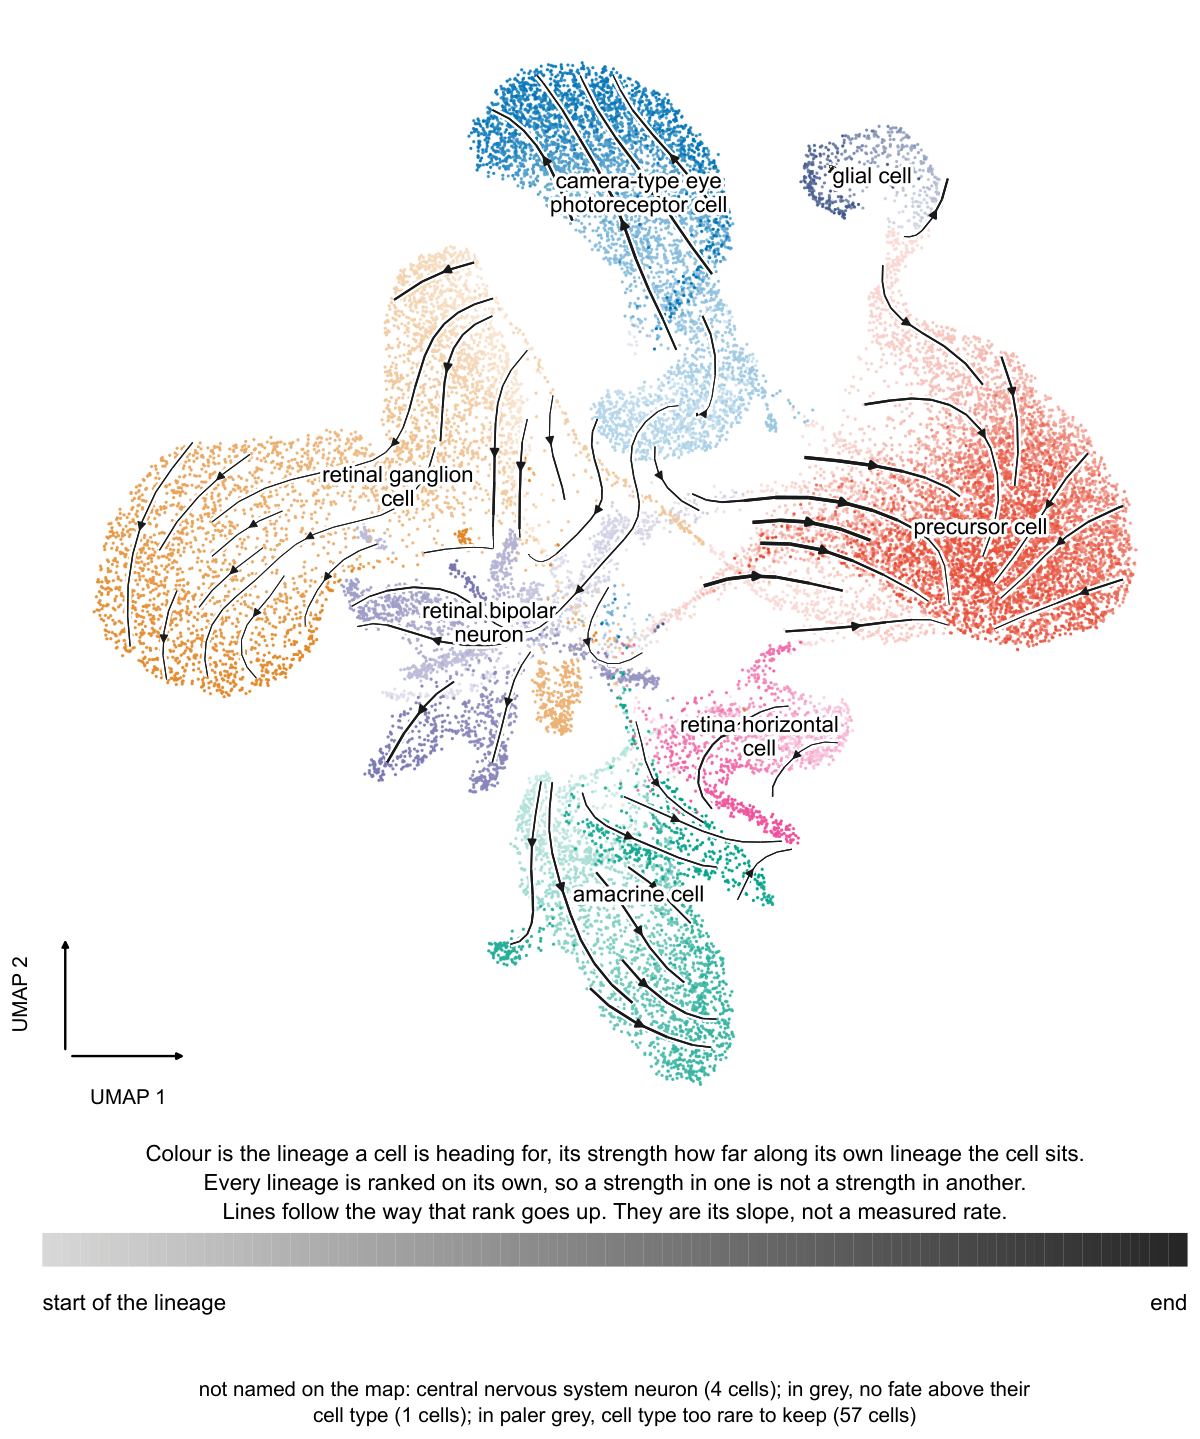

That is the **map** layout: one picture, a different hue for each lineage, and
the strength of that hue carrying the rank inside it. No colour is ever read
across two lineages, because no two lineages share a hue.

Two arguments are set above. `dot_size` is how big one cell is drawn; each
layout has its own default, suited to tens of thousands of cells, and 1.0
raises the map's from the 0.35 it would take on its own. Push it much past
this and the dense lineages fill in solid, which costs you the shading that
carries the rank.

`lines=True` draws lines following the direction the rank increases. They are
off by default because they cost a nearest-neighbour search over every cell.
The run reports what it did: it found neighbours in HECTOR's own embedding
rather than on the picture, 99.2% of the neighbour pairs it used fall inside a
single lineage, and it covered 821 of the 1,764 squares — the rest being
places with too few cells, or cells that disagreed too much to give a
direction. Expect that count to shift a little between runs, since the grid
follows the UMAP and the UMAP is recomputed each time.

**Read the lines as the slope of the rank, not as a rate**: nothing here
measured how fast anything moves. They are drawn on the map only, since each
panel already holds one lineage.

`layout` defaults to `"auto"`, which chose the map here. The choice is made by
counting: eight hues stay clearly apart on paper, so a dataset with eight
lineages or fewer gets the map and anything more gets the panels. Ask for
`layout="map"` with more lineages than that and it refuses rather than
reaching for a ninth colour nobody can name.

The other layout gives each lineage a panel of its own, the whole dataset in
grey behind it and that one lineage faded through a single hue on its own
scale. It is the better choice when the lineages overlap on the map, and it is
what you get automatically past eight lineages.

In [14]:
hector.plot_pseudotime(adata, "06_pseudotime_panels.pdf", layout="panels")

25,000 cells drawn, 8 lineages
  precursor cell                                            8,210 cells
  camera-type eye photoreceptor cell                        5,057 cells
  retinal ganglion cell                                     4,685 cells
  amacrine cell                                             2,855 cells
  retinal bipolar neuron                                    2,455 cells
  retina horizontal cell                                    1,210 cells
  glial cell                                                  466 cells
  central nervous system neuron                                 4 cells
  (no fate above their cell type)                               1 cells, not ranked
  (cell type too rare to keep)                                 57 cells, not ranked
  panel 43 x 42 mm, figure 180 x 168 mm



  wrote 06_pseudotime_panels.pdf


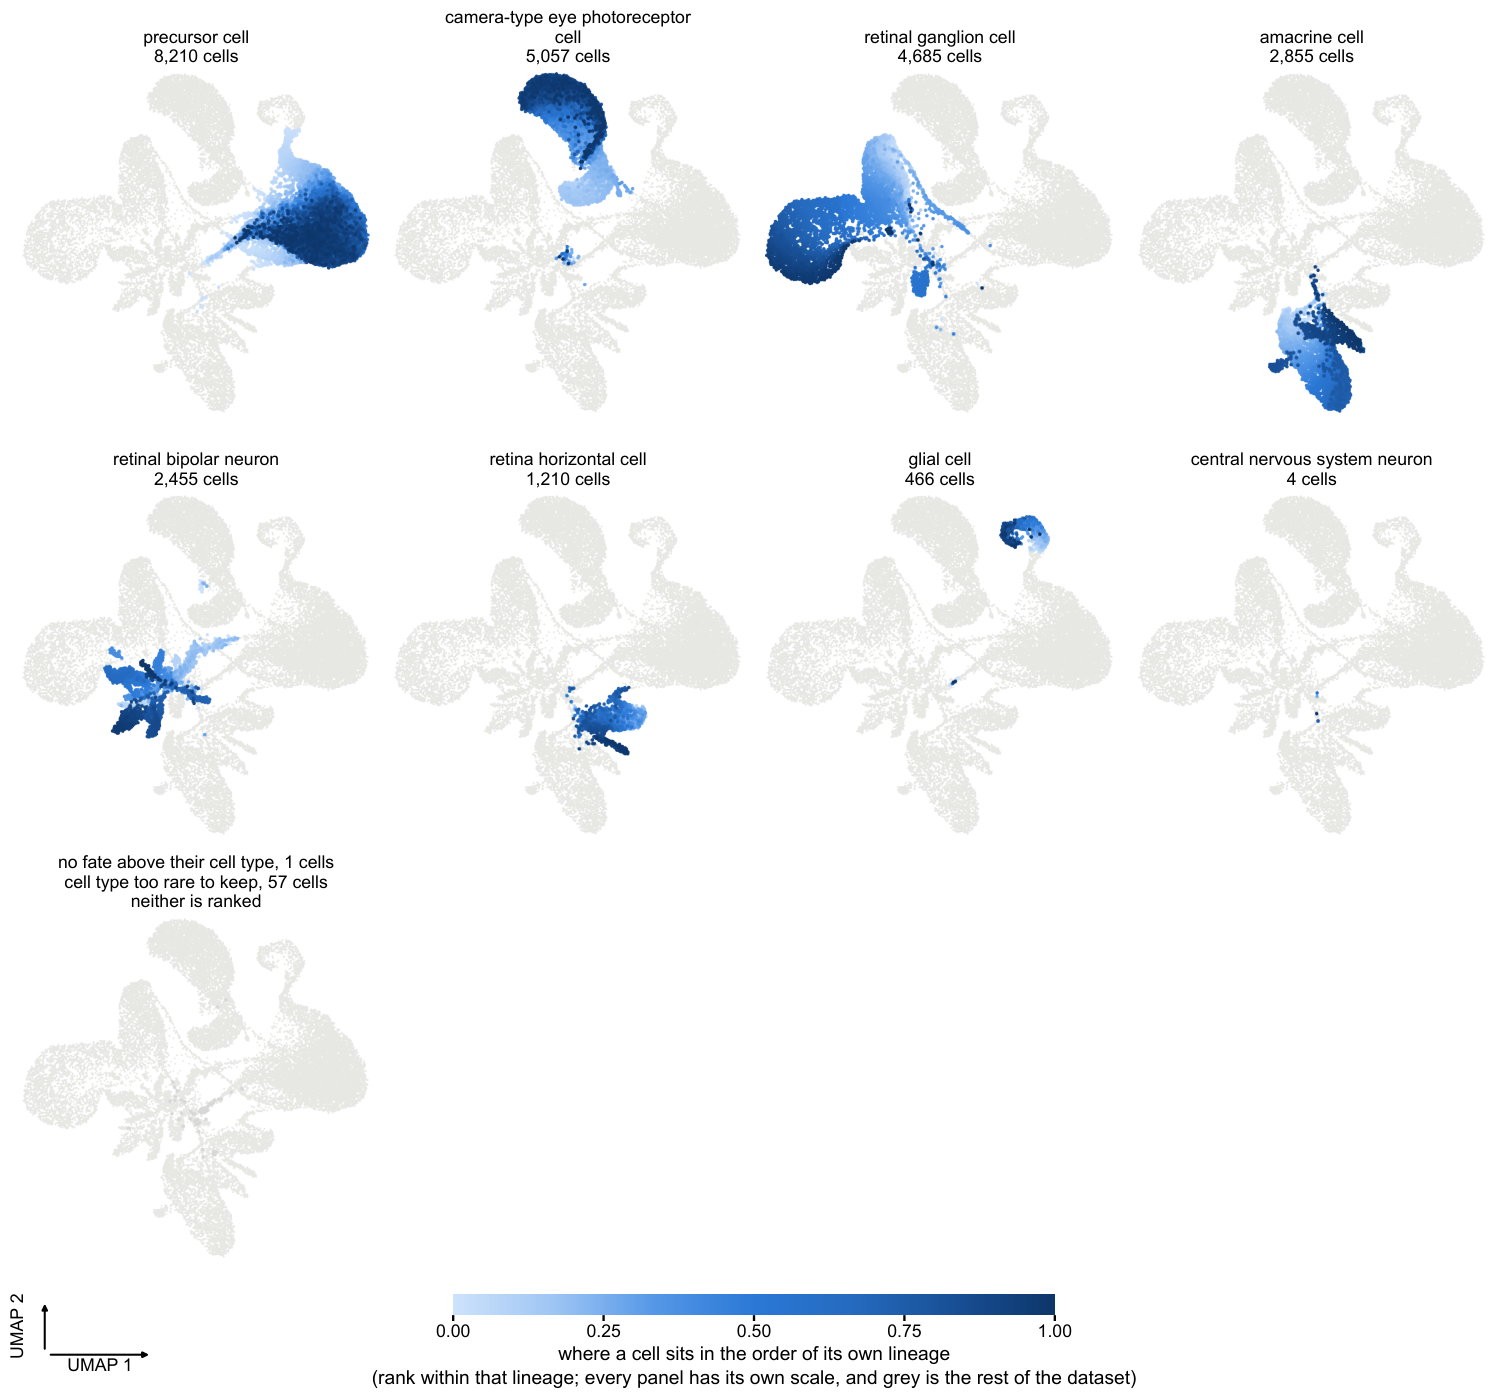

The panels keep their own default dot size, larger than the map's because each
panel shows one lineage against a grey ground rather than all of them at once.
One more argument worth knowing: `basis` names the coordinates, so a result
computed here can be drawn on any embedding you already have.

And the check drawn: for each lineage, where the authors' precursors sit against
their mature cells. The box is the middle half of the group's ranks and the pale
line inside is the median.

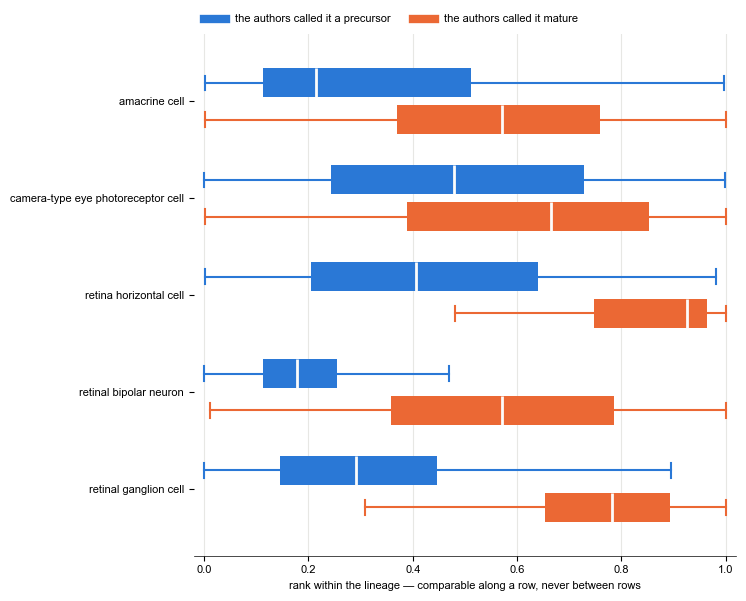

In [15]:
import matplotlib.pyplot as plt

PRECURSOR, MATURE = "#2a78d6", "#eb6834"

checked = precursors_come_first(adata)
frame = pd.DataFrame({
    "lineage": adata.obs["hector_lineage"].to_numpy(),
    "rank": adata.obs["hector_pseudotime"].to_numpy(),
    "authors_call": authors_call,
}).dropna(subset=["lineage", "rank"])

figure, axes = plt.subplots(figsize=(7.5, 0.85 * len(checked) + 1.8))
for row, lineage in enumerate(checked.index):
    part = frame[frame["lineage"] == lineage]
    # Negative shifts sit higher: the y axis is inverted below.
    for shift, (call, colour) in zip((-0.19, 0.19),
                                     [("precursor", PRECURSOR),
                                      ("mature", MATURE)]):
        box = axes.boxplot(part.loc[part["authors_call"] == call, "rank"],
                           positions=[row + shift], widths=0.3, vert=False,
                           showfliers=False, patch_artist=True)
        box["boxes"][0].set(facecolor=colour, edgecolor=colour, linewidth=0)
        box["medians"][0].set(color="#fcfcfb", linewidth=2)
        for piece in ("whiskers", "caps"):
            for line in box[piece]:
                line.set(color=colour, linewidth=1.5)

axes.set_yticks(range(len(checked)))
axes.set_yticklabels(checked.index, fontsize=8)
axes.invert_yaxis()  # top to bottom in the same order as the table above
axes.set_xlabel("rank within the lineage — comparable along a row, never between "
                "rows", fontsize=8)
axes.set_xlim(-0.02, 1.02)
axes.tick_params(labelsize=8)
axes.grid(axis="x", color="#e7e7e4", linewidth=0.8)
axes.set_axisbelow(True)
for edge in ("top", "right", "left"):
    axes.spines[edge].set_visible(False)
axes.legend(handles=[plt.Line2D([], [], color=PRECURSOR, linewidth=6,
                                label="the authors called it a precursor"),
                     plt.Line2D([], [], color=MATURE, linewidth=6,
                                label="the authors called it mature")],
            fontsize=8, frameon=False, loc="lower left",
            bbox_to_anchor=(0, 1.0), ncol=2)
figure.tight_layout()
figure.savefig("06_pseudotime_check.pdf")

## What the number means, and what it does not

**It is an order, not an amount.** A value of 0.5 means half the cells of that
lineage come before this one. It does not mean half way along the lineage. The
gap between two cells' values is not an amount of anything, and a single cell's
value is not a quantity to quote.

**Values from different lineages are never comparable.** Two cells at 0.5 in
different lineages are each at the same place in their own order, not at the
same moment in development. This is the failure a single number per cell cannot
avoid, and the reason each lineage is ranked on its own. Step 6 is what it looks
like when two paths end up inside one lineage anyway.

**What it is good for**: ordering cell types along a branch, which is what Step
7 tests. Whether it can order two cells *of the same cell type* — two cells on
the same edge, with no difference in cell type to separate them — is a separate
claim that this check cannot reach, and rods and cones are exactly the case
where it would have to carry the result alone.

**What it will not tell you is when.** This atlas covers ten fetal weeks and it
is tempting to read the ranks as time. Do not: six of the nine major classes
here are present in every one of those weeks, so a cell's rank within its
lineage is not an estimate of its age. What changes across the weeks is how many
cells sit at each stage, which is a statement about the population and not about
any cell in it.